# Implementing a quantum key distribution protocol (BB84)

$$\renewcommand{\ket}[1]{|#1\rangle}$$
$$\renewcommand{\bra}[1]{\langle#1|}$$


The BB84 protocol is one of the first quantum key distribution protocols proposed. It is named after the inventors Charles H. Bennett and Gilles Brassard, and the year of publication (1984). 

The goal is for Alice and Bob to generate a shared key between them, in a way that makes it difficult for an eavesdropper to also have access to the key. The way we one can use qubits to this end is to leverage the facts that 

- Measuring a qubit can be probabilistic in its outcome

- Measuring a qubit entirely depends on *how* you measure it. That is, the measurement by definition depends on the basis or observable you measure with respect to. 

For this quantum key distribution protocol, we assume that Alice and Bob have access to two kinds of communication channels. We suppose that we have one unidirectional *quantum* channel, that allows for the sending of qubits in one direction (these will go from Alice to Bob). We furthermore suppose that we have one bidirectional *classical* channel, that allows for the transmission of classical bits in both directions.

We also assume that Alice and Bob both have a common implementation of a qubit. That is, each qubit has a fixed computational basis of states. Alice may have different physical qubits than Bob, but they should agree on what state represents $\ket{0}$ and what state represents $\ket{1}$. 


The BB84 protocol works as follows. 

1. Alice prepares states for a collection of individual qubits according to two decisions. Alice must decide on a classical bit value ($0$ or $1$), and she must decide on a basis to encode these classical bit values onto: Alice can pick between the standard computational basis (Z-basis) $\{ \ket{0}, \ket{1} \} $ or the Hadamard basis (X-basis) $\{ \ket{+} , \ket{-} \}$. She will make these decisions randomly: picking the classical bit value with a 50% chance for either $0$ or $1$, and picking the type of basis with a 50% chance for either the Z-basis or the X-basis. For each choice she ends up making, she will record the choice made in a classical fashion. 

2. After preparing her qubits, she sends them to Bob through the available quantum channel. Once Bob receives these qubits, he will take the qubits and perform his own measurements. For each qubit received, Bob will choose randomly between (again, in a uniform manner) the standard computational basis and the Hadamard basis. Similar to Alice, for each choice Bob ends up making, he will record the choice made in a classical fashion. 

3. Now both Alice and Bob are in possession of a string of classical bits. Alice obtained her classical bits by generating random classical bit values in step 1. , and Bob obtained his classical bits by measuring the qubits received from Alice with respect to his randomly chosen basis. The important insight here is to note that if Alice and Bob *somehow* managed (by some miracle) to pick exactly the same basis for each qubit, they will have the *same* string of classical bits. On the other hand, for each basis incorrectly chosen by Bob, there is a 50% chance that Bob's measurement will result in a classical bit which is different from Alice's bit. This leads us to the next step...

4. Alice and Bob use the classical communication channel to transmit their respective lists of bases that were used. When Alice receives the list of bases that Bob used, and Bob receives the list of bases that Alice used, they will be able to discern which bases they happened to agree on. Note that they only have to use the classical communication channel one time! 

5. Every classical bit value in Alice and Bob's respective list of bits, corresponding to an index for which the two chosen bases are in agreement, will be in agreement. Alice and Bob can discard the rest of the bits, and keep only these bits that are in agreement. 

Now Alice and Bob share a randomly generated key! 

In this lab, we will simulate this protocol with qiskit. First, by the way qubits are managed in qiskit, we have to define a global circuit that represents the entire state space of the protocol. There is no way to "send" qubits around, but we can define a global environment where everything happens.

In [ ]:
## Start by defining a global BB84 quantum circuit, this will be the "global environment where everything happens". 
# This circuit should be initialized with the correct number of qubits that we will be needing for this protocol. 
# Choose some initial number of (qu)bits to your liking. Note that this number will be the upper bound for the key size, 
# and that we will have to throw away a good number of these bits.


## your code here 


One can use qiskit "barriers" to compartmentalize different parts of a circuit. Below is an example. From a high level perspectively, this is primarily for visual purposes and does not really "do anything". From a low level perspective, it is related to how Qiskit chooses to optimize circuits before running them.

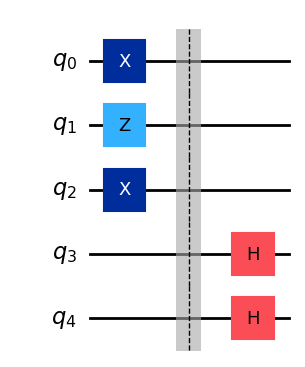

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Barrier 

qc = QuantumCircuit(5)
qc.x(0)
qc.z(1)
qc.x(2)
qc.barrier()
qc.h(3)
qc.h(4)

qc.draw('mpl')

 

In [ ]:
### Simulate Alice's actions. For the size N of register chosen above, we must have 2*N choices. A bit value, and a basis. For each pair of choices, add appropriate gates 
### to our global environment circuit to prepare the qubits accordingly. Record classically the random choices that were made. You can do this with standard python objects, or
### you can try this with by adding a classical register to the circuit and writing classical bit values to the register.

In [ ]:
### Simulate Bob's actions. Since "Alice and Bob's environments" live in the same circuit, we can use the logical left-to-right flow of the circuit to simulate 
### the "sending" of qubits (even with a barrier, qubits can pass through to the segmented parts of a circuit).
### Once the qubits reach Bob's part of the circuit (delineated by a barrier, if you used one), pick some random bases. Record the choices. 
### Measure qubits with respect to choices of bases, record measurement results. This should produce Bob's string of classical bits.  

<u>Question</u>:

Suppose now that we introduce a potential eavesdropper, Eve. In what way is this protocol resilient to eavesdropping? To think about this, consider the *no-cloning theorem*. 
Alice will be sending qubits to Bob, and Bob is expecting to receive qubits. Eve will eventually have to send qubits to Bob, or else the protocol will not continue (and no key will be generated). 


Try to experiment with introducing Eve into the global circuit environment and see what happens... 